## Đánh giá & So sánh Thuật toán: Logistic Regression | Random Forest | XGBoost

## 1. Import thư viện & Cấu hình

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from xgboost import XGBClassifier, callback
import joblib
import time

# Matplotlib config
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='husl')

RANDOM_STATE = 42
print('Libraries imported successfully')

Libraries imported successfully


## 2. Tải & Khám phá Dữ liệu (EDA)

In [2]:
df = pd.read_csv('dataset/train.csv')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Shape: (165034, 14)

Columns: ['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [3]:
# print('='*50)
# print('THỐNG KÊ MÔ TẢ')
# print('='*50)
# display(df.describe())

print('\n Missing Values:')
print(df.isnull().sum())

print(f'\n Target Distribution:')
vc = df['Exited'].value_counts()
print(f'  Ở lại (0):   {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)')
print(f'  Rời bỏ (1): {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)')


 Missing Values:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

 Target Distribution:
  Ở lại (0):   130,113 (78.8%)
  Rời bỏ (1): 34,921 (21.2%)


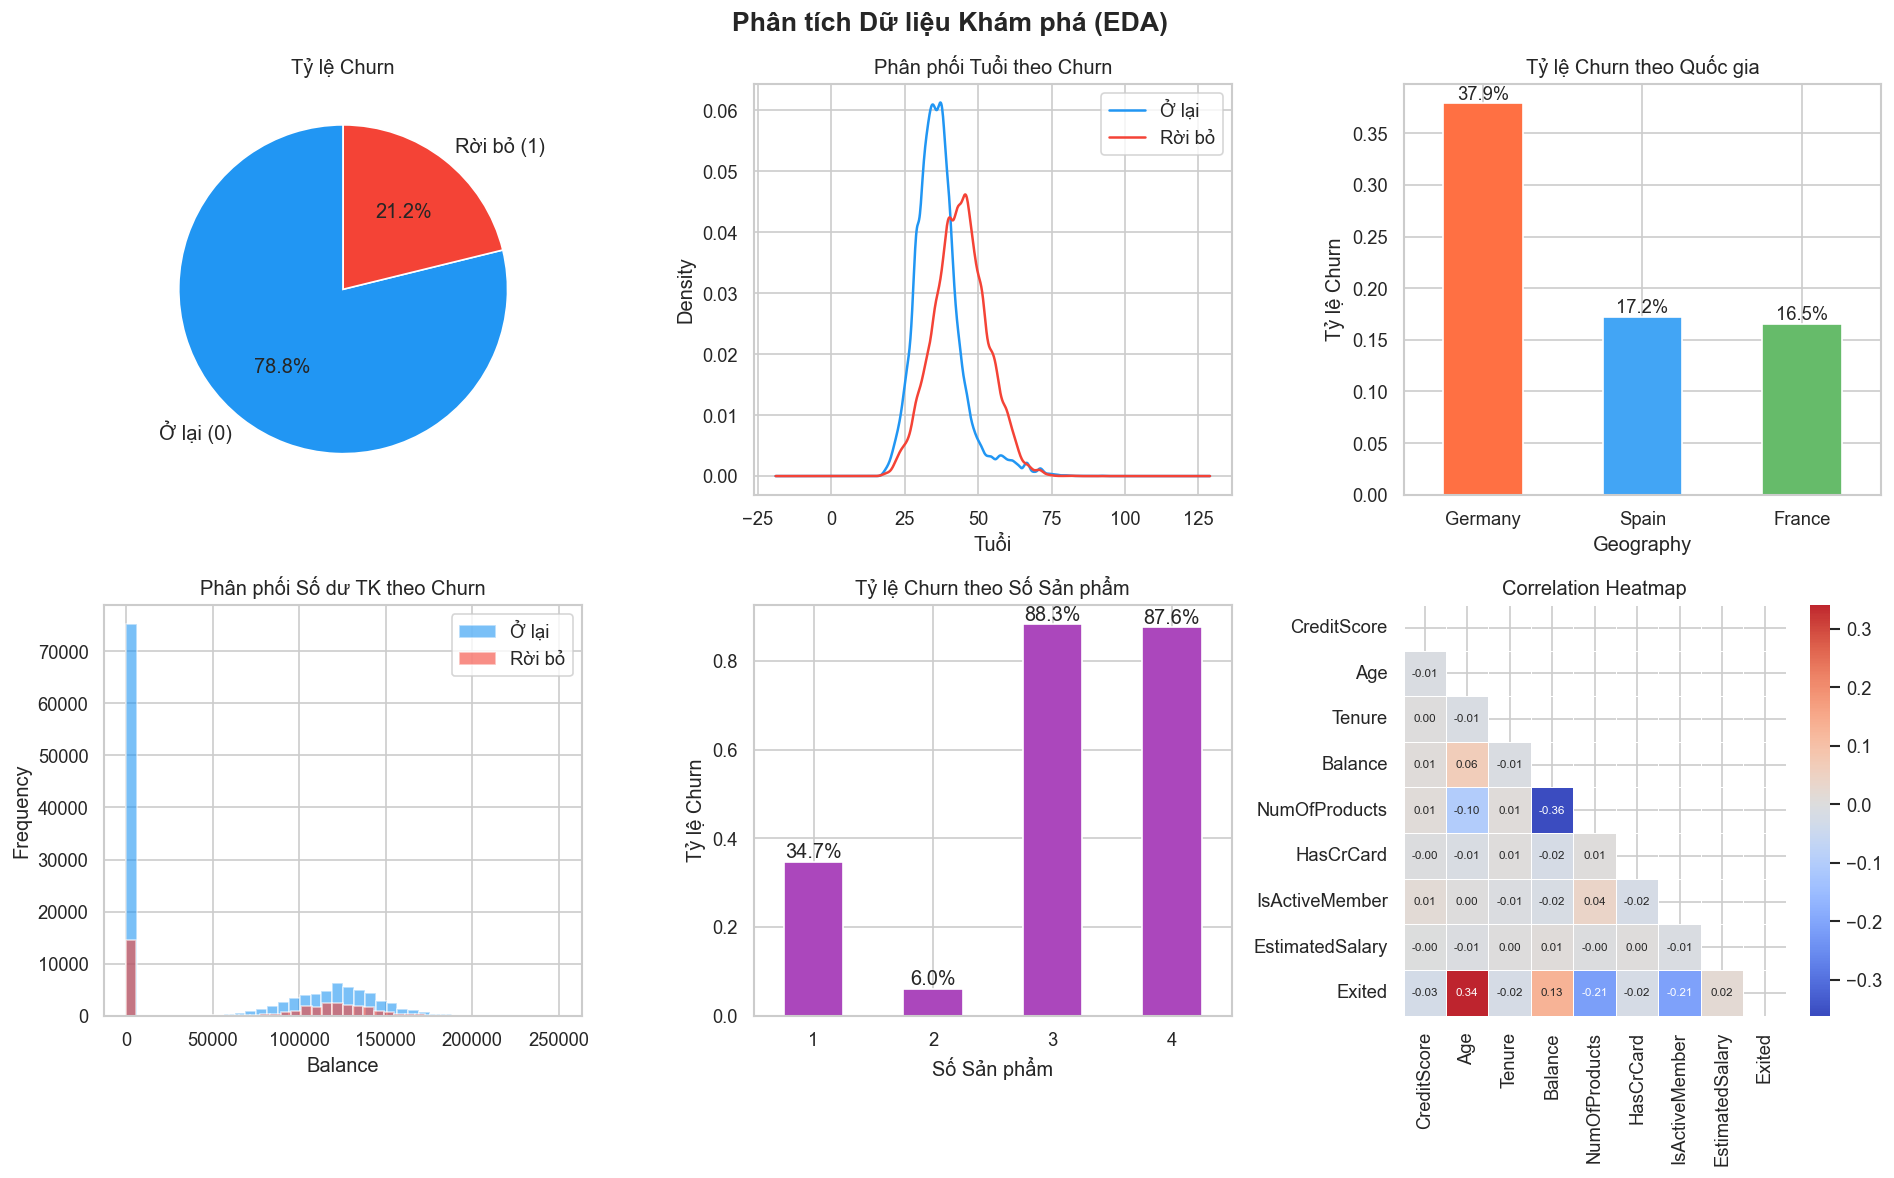

EDA plots saved


In [4]:
# ── EDA Visualizations ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Phân tích Dữ liệu Khám phá (EDA)', fontsize=16, fontweight='bold')

# 1. Target distribution
ax = axes[0, 0]
colors = ['#2196F3', '#F44336']
labels = ['Ở lại (0)', 'Rời bỏ (1)']
ax.pie(vc.values, labels=labels, colors=colors, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 12})
ax.set_title('Tỷ lệ Churn')

# 2. Age distribution
ax = axes[0, 1]
df[df['Exited']==0]['Age'].plot(kind='kde', ax=ax, label='Ở lại', color='#2196F3')
df[df['Exited']==1]['Age'].plot(kind='kde', ax=ax, label='Rời bỏ', color='#F44336')
ax.set_title('Phân phối Tuổi theo Churn')
ax.set_xlabel('Tuổi')
ax.legend()

# 3. Geography churn rate
ax = axes[0, 2]
geo_churn = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
geo_churn.plot(kind='bar', ax=ax, color=['#FF7043','#42A5F5','#66BB6A'], edgecolor='white')
ax.set_title('Tỷ lệ Churn theo Quốc gia')
ax.set_ylabel('Tỷ lệ Churn')
ax.set_xticklabels(geo_churn.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

# 4. Balance distribution
ax = axes[1, 0]
df[df['Exited']==0]['Balance'].plot(kind='hist', bins=40, ax=ax, alpha=0.6,
                                     label='Ở lại', color='#2196F3')
df[df['Exited']==1]['Balance'].plot(kind='hist', bins=40, ax=ax, alpha=0.6,
                                     label='Rời bỏ', color='#F44336')
ax.set_title('Phân phối Số dư TK theo Churn')
ax.set_xlabel('Balance')
ax.legend()

# 5. NumOfProducts vs Churn
ax = axes[1, 1]
prod_churn = df.groupby('NumOfProducts')['Exited'].mean()
prod_churn.plot(kind='bar', ax=ax, color='#AB47BC', edgecolor='white')
ax.set_title('Tỷ lệ Churn theo Số Sản phẩm')
ax.set_xlabel('Số Sản phẩm')
ax.set_ylabel('Tỷ lệ Churn')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

# 6. Correlation heatmap (numeric)
ax = axes[1, 2]
num_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
            'HasCrCard','IsActiveMember','EstimatedSalary','Exited']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.5, square=False)
ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('models/eda_overview.png', bbox_inches='tight')
plt.show()
print('EDA plots saved')

## 3. Tiền xử lý Dữ liệu

In [5]:
DROP_COLS = ['id', 'CustomerId', 'Surname']
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS + ['Exited']]
TARGET = 'Exited'

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

# Label Encoding cho categorical features
le_geo = LabelEncoder()
le_gen = LabelEncoder()
X['Geography'] = le_geo.fit_transform(X['Geography'])
X['Gender']    = le_gen.fit_transform(X['Gender'])

print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'\nGeography encoding: {dict(zip(le_geo.classes_, le_geo.transform(le_geo.classes_)))}')
print(f'Gender encoding:    {dict(zip(le_gen.classes_, le_gen.transform(le_gen.classes_)))}')

# Train/Validation split (80/20, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scaled version for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print(f'\nTrain: {X_train.shape} | Val: {X_val.shape}')
print(f'Train churn rate: {y_train.mean():.3f}')
print(f'Val churn rate:   {y_val.mean():.3f}')

Feature columns (10): ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Geography encoding: {'France': 0, 'Germany': 1, 'Spain': 2}
Gender encoding:    {'Female': 0, 'Male': 1}

Train: (132027, 10) | Val: (33007, 10)
Train churn rate: 0.212
Val churn rate:   0.212


## 4. Huấn luyện 3 Mô hình

### 4.1 Logistic Regression 

In [6]:
print('Training Logistic Regression...')
t0 = time.time()

lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr.fit(X_train_scaled, y_train)

lr_time = time.time() - t0
lr_prob_val  = lr.predict_proba(X_val_scaled)[:, 1]
lr_pred_val  = lr.predict(X_val_scaled)

print(f' Done in {lr_time:.1f}s')
print(f'   Val AUC:      {roc_auc_score(y_val, lr_prob_val):.4f}')
print(f'   Val Accuracy: {accuracy_score(y_val, lr_pred_val):.4f}')
print(f'   Val F1:       {f1_score(y_val, lr_pred_val):.4f}')

Training Logistic Regression...
 Done in 2.7s
   Val AUC:      0.8064
   Val Accuracy: 0.7431
   Val F1:       0.5456


### 4.2 Random Forest 

In [7]:
print(' Training Random Forest...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_time = time.time() - t0
rf_prob_val = rf.predict_proba(X_val)[:, 1]
rf_pred_val = rf.predict(X_val)

print(f' Done in {rf_time:.1f}s')
print(f'   Val AUC:      {roc_auc_score(y_val, rf_prob_val):.4f}')
print(f'   Val Accuracy: {accuracy_score(y_val, rf_pred_val):.4f}')
print(f'   Val F1:       {f1_score(y_val, rf_pred_val):.4f}')

 Training Random Forest...
 Done in 5.6s
   Val AUC:      0.8867
   Val Accuracy: 0.8289
   Val F1:       0.6515


### 4.3 XGBoost

In [8]:
print(' Training XGBoost...')
t0 = time.time()

# Tính scale_pos_weight cho imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f'   scale_pos_weight = {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    n_jobs=-1,
    verbosity=0
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_time = time.time() - t0
xgb_prob_val = xgb.predict_proba(X_val)[:, 1]
xgb_pred_val = xgb.predict(X_val)

print(f' Done in {xgb_time:.1f}s')
print(f'   Val AUC:      {roc_auc_score(y_val, xgb_prob_val):.4f}')
print(f'   Val Accuracy: {accuracy_score(y_val, xgb_pred_val):.4f}')
print(f'   Val F1:       {f1_score(y_val, xgb_pred_val):.4f}')

 Training XGBoost...
   scale_pos_weight = 3.73
 Done in 3.7s
   Val AUC:      0.8894
   Val Accuracy: 0.8186
   Val F1:       0.6463


## 5. So sánh Hiệu suất Mô hình

In [9]:
def get_metrics(y_true, y_pred, y_prob, model_name, train_time):
    return {
        'Model': model_name,
        'AUC-ROC': round(roc_auc_score(y_true, y_prob), 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1-Score': round(f1_score(y_true, y_pred), 4),
        'Avg Precision': round(average_precision_score(y_true, y_prob), 4),
        'Train Time (s)': round(train_time, 2),
    }

metrics_list = [
    get_metrics(y_val, lr_pred_val,  lr_prob_val,  'Logistic Regression', lr_time),
    get_metrics(y_val, rf_pred_val,  rf_prob_val,  'Random Forest ',     rf_time),
    get_metrics(y_val, xgb_pred_val, xgb_prob_val, 'XGBoost',             xgb_time),
]

metrics_df = pd.DataFrame(metrics_list).set_index('Model')

# Highlight best values
styled = metrics_df.style \
    .highlight_max(subset=['AUC-ROC','Accuracy','Precision','Recall','F1-Score','Avg Precision'],
                   color='#C8E6C9') \
    .highlight_min(subset=['Train Time (s)'], color='#C8E6C9') \
    .format({'AUC-ROC':'{:.4f}','Accuracy':'{:.4f}',
             'Precision':'{:.4f}','Recall':'{:.4f}',
             'F1-Score':'{:.4f}','Avg Precision':'{:.4f}',
             'Train Time (s)':'{:.2f}s'})

print(' BẢNG SO SÁNH HIỆU SUẤT (Validation Set):')
display(styled)
# metrics_df

 BẢNG SO SÁNH HIỆU SUẤT (Validation Set):


,AUC-ROC,Accuracy,Precision,Recall,F1-Score,Avg Precision,Train Time (s)
Model,,,,,,,
Logistic Regression,0.8064,0.7431,0.4359,0.7290,0.5456,0.5381,2.65s
Random Forest,0.8867,0.8289,0.5725,0.7557,0.6515,0.7195,5.58s
XGBoost,0.8894,0.8186,0.5501,0.7834,0.6463,0.7296,3.66s


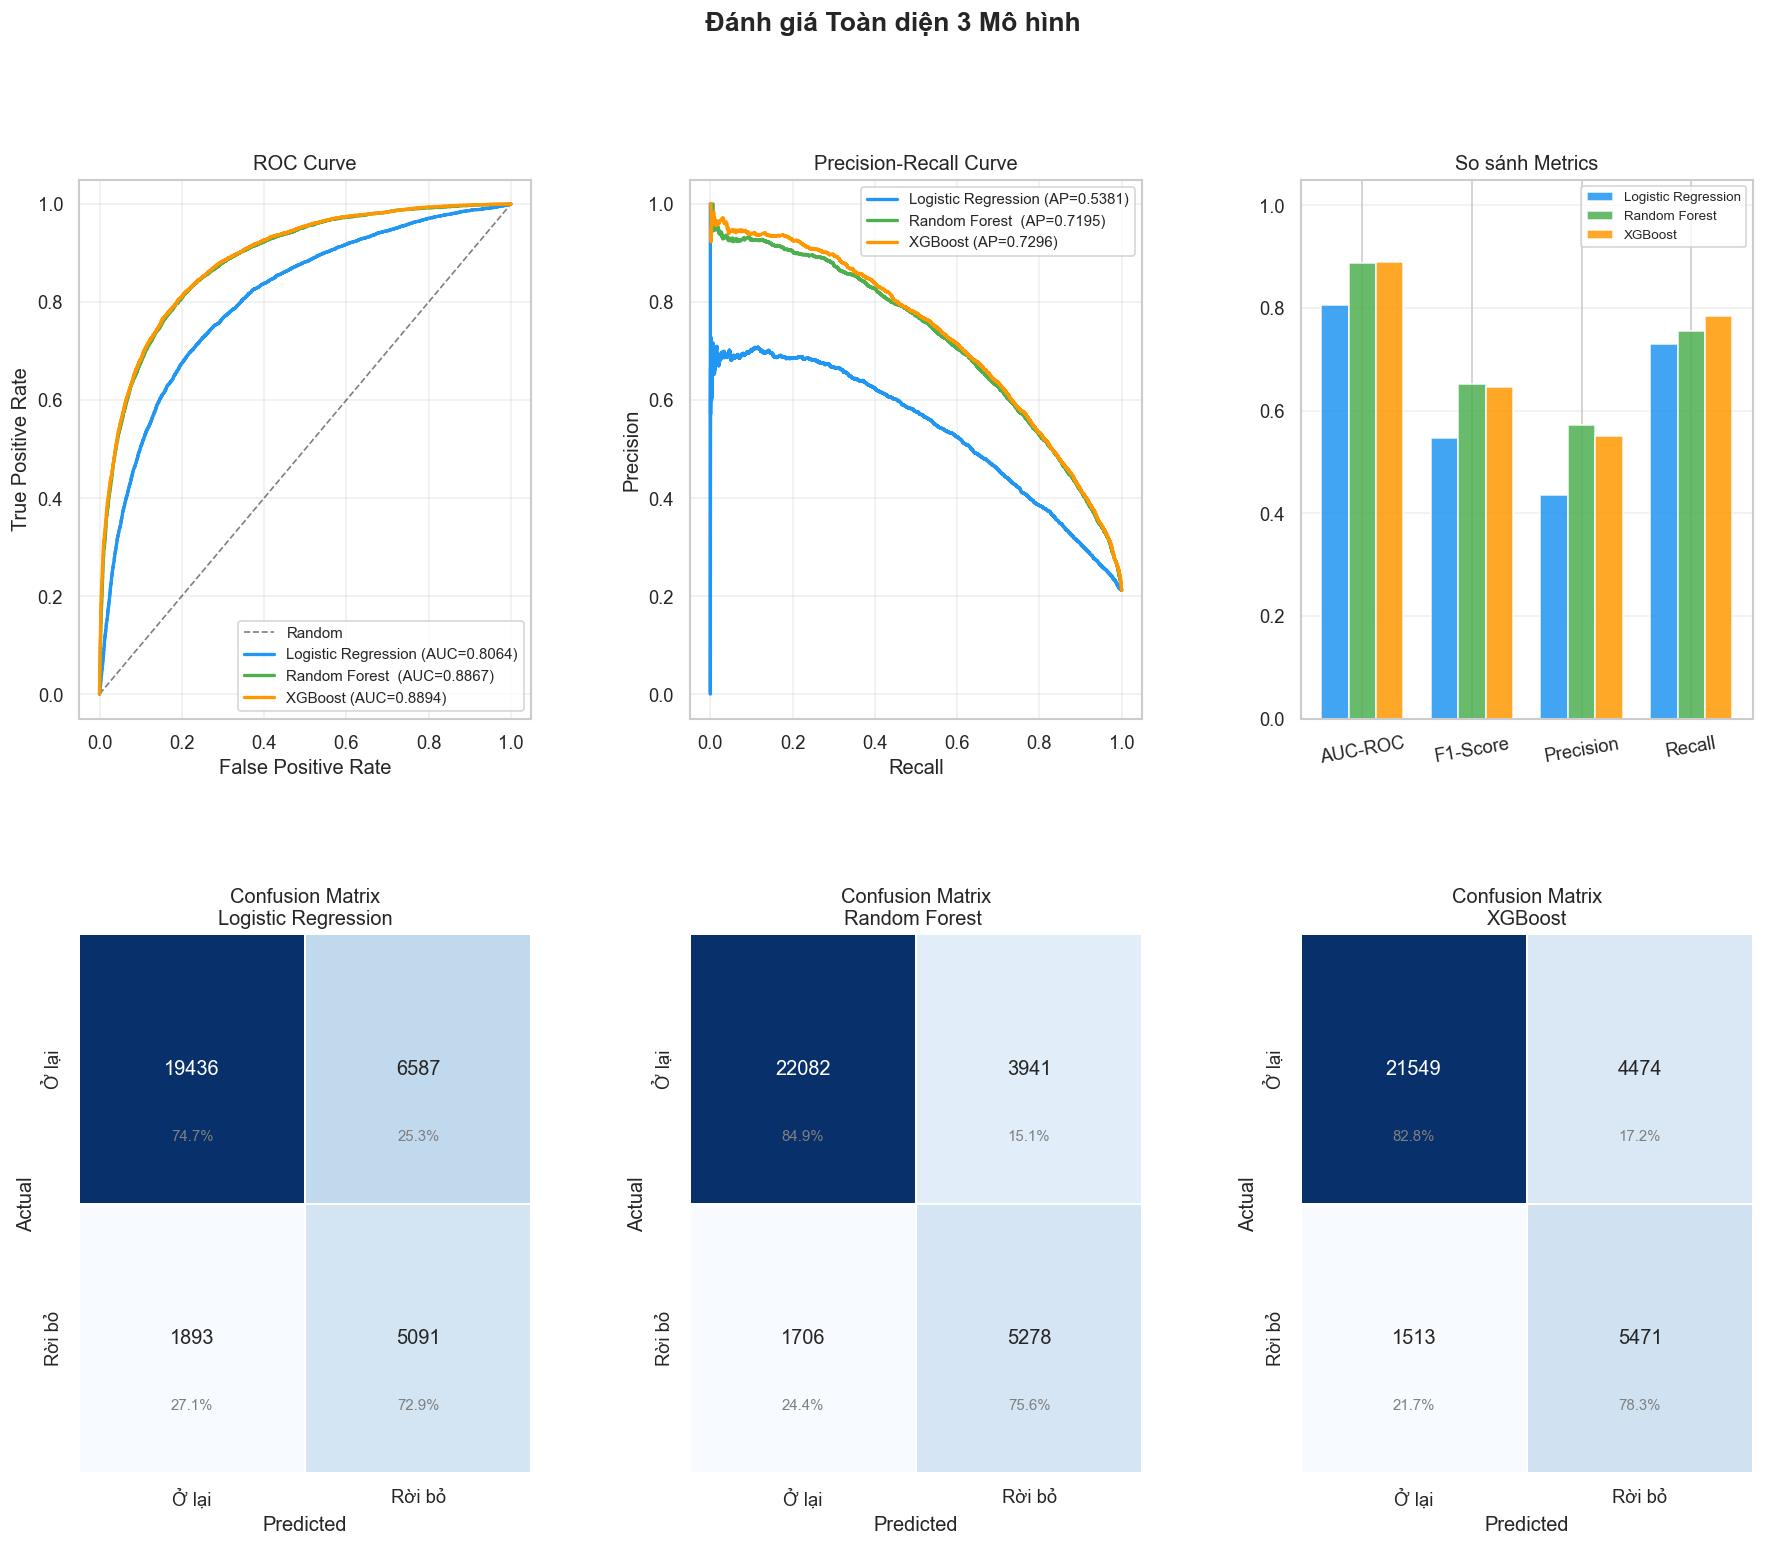

 Comparison plots saved


In [10]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle(' Đánh giá Toàn diện 3 Mô hình', fontsize=16, fontweight='bold')

models_info = [
    ('Logistic Regression', lr_prob_val,  lr_pred_val,  '#2196F3'),
    ('Random Forest ',     rf_prob_val,  rf_pred_val,  '#4CAF50'),
    ('XGBoost',             xgb_prob_val, xgb_pred_val, '#FF9800'),
]

# ── ROC Curves (top-left) ──
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot([0,1],[0,1],'k--', linewidth=1, label='Random', alpha=0.5)
for name, proba, pred, color in models_info:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=9)
ax_roc.grid(True, alpha=0.3)

# ── PR Curves (top-center) ──
ax_pr = fig.add_subplot(gs[0, 1])
for name, proba, pred, color in models_info:
    precision_c, recall_c, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    ax_pr.plot(recall_c, precision_c, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')
ax_pr.set_title('Precision-Recall Curve')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(fontsize=9)
ax_pr.grid(True, alpha=0.3)

# ── Bar comparison (top-right) ──
ax_bar = fig.add_subplot(gs[0, 2])
metrics_plot = ['AUC-ROC', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics_plot))
w = 0.25
colors_bar = ['#2196F3', '#4CAF50', '#FF9800']
for i, (row_name, _, _, color) in enumerate(models_info):
    model_key = row_name
    row = metrics_df.loc[model_key, metrics_plot].values.astype(float)
    bars = ax_bar.bar(x + i*w, row, w, label=row_name, color=colors_bar[i], alpha=0.85)
ax_bar.set_title('So sánh Metrics')
ax_bar.set_xticks(x + w)
ax_bar.set_xticklabels(metrics_plot, rotation=10)
ax_bar.set_ylim(0, 1.05)
ax_bar.legend(fontsize=8)
ax_bar.grid(axis='y', alpha=0.3)

# ── Confusion Matrices (bottom row) ──
for col_idx, (name, proba, pred, color) in enumerate(models_info):
    ax_cm = fig.add_subplot(gs[1, col_idx])
    cm = confusion_matrix(y_val, pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Ở lại','Rời bỏ'],
                yticklabels=['Ở lại','Rời bỏ'],
                linewidths=1, linecolor='white', cbar=False)
    # Overlay percentages
    for i in range(2):
        for j in range(2):
            ax_cm.text(j+0.5, i+0.75, f'{cm_pct[i,j]:.1%}',
                       ha='center', va='center', fontsize=9, color='gray')
    ax_cm.set_title(f'Confusion Matrix\n{name}')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')

plt.savefig('models/model_comparison.png', bbox_inches='tight')
plt.show()
print(' Comparison plots saved')

## 6. Huấn luyện lại mô hình XGBoost

In [15]:
print(' Training XGBoost...')
t0 = time.time()

# Tính scale_pos_weight cho imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f'   scale_pos_weight = {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=2000,
    max_depth=5,
    learning_rate=0.02,
    early_stopping_rounds=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    tree_method='hist',
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_time = time.time() - t0
xgb_prob_val = xgb.predict_proba(X_val)[:, 1]
xgb_pred_val = xgb.predict(X_val)

# ── Validation Metrics ────────────────────────────────────────────
print(f'\n XGBoost — Done in {xgb_time:.1f}s')
print('=' * 55)
print(f'  Best iteration   : {xgb.best_iteration}')          # ← early stopping dừng ở cây thứ mấy
print('-' * 55)
print(f'  AUC-ROC          : {roc_auc_score(y_val, xgb_prob_val):.4f}')
print(f'  Accuracy         : {accuracy_score(y_val, xgb_pred_val):.4f}')
print(f'  Precision        : {precision_score(y_val, xgb_pred_val):.4f}')
print(f'  Recall           : {recall_score(y_val, xgb_pred_val):.4f}')
print(f'  F1-Score         : {f1_score(y_val, xgb_pred_val):.4f}')
print(f'  Avg Precision    : {average_precision_score(y_val, xgb_prob_val):.4f}')
print('=' * 55)
print(classification_report(y_val, xgb_pred_val,
                             target_names=['Stay (0)', 'Churn (1)']))

 Training XGBoost...
   scale_pos_weight = 3.73

 XGBoost — Done in 6.7s
  Best iteration   : 573
-------------------------------------------------------
  AUC-ROC          : 0.8902
  Accuracy         : 0.8163
  Precision        : 0.5454
  Recall           : 0.7927
  F1-Score         : 0.6462
  Avg Precision    : 0.7308
              precision    recall  f1-score   support

    Stay (0)       0.94      0.82      0.88     26023
   Churn (1)       0.55      0.79      0.65      6984

    accuracy                           0.82     33007
   macro avg       0.74      0.81      0.76     33007
weighted avg       0.85      0.82      0.83     33007



In [12]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 100)

best_t = 0.5
best_f1 = 0

for t in thresholds:
    y_pred = (xgb_prob_val > t).astype(int)
    f1 = f1_score(y_val, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.6575757575757576
Best F1: 0.6663858466722831


## 7. Tạo Prediction trên Test Set & Lưu Model

In [13]:
df_test = pd.read_csv('dataset/test.csv')
X_test = df_test[FEATURE_COLS].copy()
X_test['Geography'] = le_geo.transform(X_test['Geography'])
X_test['Gender']    = le_gen.transform(X_test['Gender'])

test_proba = rf.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': df_test['id'],
    'Exited': np.round(test_proba, 6)
})
submission.to_csv('dataset/submission_rf.csv', index=False)
print(f' Submission saved: {len(submission)} rows')
print(f'   Churn rate (pred): {(test_proba >= 0.5).mean():.3f}')
submission.head(10)

 Submission saved: 110023 rows
   Churn rate (pred): 0.282


,id,Exited
0,165034,0.066154
1,165035,0.958678
2,165036,0.110013
3,165037,0.482354
4,165038,0.578300
5,165039,0.175871
6,165040,0.149419
7,165041,0.258678
8,165042,0.814201
9,165043,0.031311


In [14]:
import json

joblib.dump(xgb, 'models/xgboost.pkl')
joblib.dump(le_geo, 'models/le_geography.pkl')
joblib.dump(le_gen, 'models/le_gender.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

meta = {
    'features': FEATURE_COLS,
    'geography_classes': le_geo.classes_.tolist(),
    'gender_classes': le_gen.classes_.tolist(),
    'best_threshold': float(best_t),
    'val_metrics': {
        'logistic_regression': {
            'auc': round(roc_auc_score(y_val, lr_prob_val), 4),
            'f1':  round(f1_score(y_val, lr_pred_val), 4),
        },
        'random_forest': {
            'auc': round(roc_auc_score(y_val, rf_prob_val), 4),
            'f1':  round(f1_score(y_val, rf_pred_val), 4),
        },
        'xgboost': {
            'auc': round(roc_auc_score(y_val, xgb_prob_val), 4),
            'f1':  round(f1_score(y_val, xgb_pred_val), 4),
        },
    }
}
with open('models/meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(' Tất cả models đã được lưu:')
print('   models/xgboost.pkl')
print('   models/le_geography.pkl')
print('   models/le_gender.pkl')
print('   models/scaler.pkl')
print('   models/meta.json')

 Tất cả models đã được lưu:
   models/xgboost.pkl
   models/le_geography.pkl
   models/le_gender.pkl
   models/scaler.pkl
   models/meta.json
